# Interactive Scatter Plot of World Population Data
In this example, we visualize Gapminder demographic data using an interactive scatter plot. The input is implemented with ipywidgets.
### Remark
This version is adapted for VS Code notebooks and uses Matplotlib with `ipympl`, which is more reliable here than Bokeh notebook updates.

IntSlider(value=1964, continuous_update=False, description='Year', layout=Layout(height='40px', width='500px')…

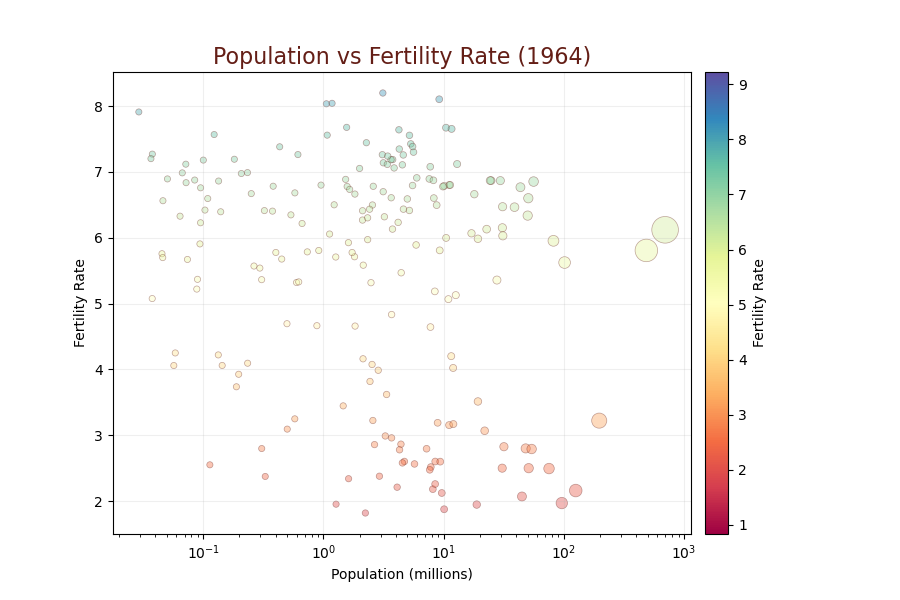

In [1]:
%matplotlib ipympl

from bokeh.sampledata.gapminder import population as pop
from bokeh.sampledata.gapminder import fertility as fert
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from ipywidgets import Layout
import ipywidgets as widgets

fert = fert.dropna()
pop = pop.drop(pop.index.difference(fert.index))
pop = pop / 1_000_000  # population in millions

max_fert = fert.max().max()
min_fert = fert.min().min()
max_pop = pop.max().max()
min_pop = pop.min().min()

def radii(population, min_population, max_population):
    """Scale circle sizes by population."""
    min_radius = 20
    max_radius = 700
    return min_radius + (population - min_population) / (max_population - min_population) * (max_radius - min_radius)

fig, ax = plt.subplots(figsize=(9, 6))
fig.canvas.header_visible = False

norm = Normalize(vmin=min_fert, vmax=max_fert)
cmap = plt.get_cmap('Spectral')
scalar_mappable = ScalarMappable(norm=norm, cmap=cmap)
colorbar = fig.colorbar(scalar_mappable, ax=ax, pad=0.02)
colorbar.set_label('Fertility Rate')

scatter = None

def redraw(year):
    global scatter
    year_key = str(year)

    x = pop[year_key]
    y = fert[year_key]
    sizes = radii(pop[year_key], min_pop, max_pop)
    colors = fert[year_key]

    ax.clear()
    scatter = ax.scatter(
        x,
        y,
        s=sizes,
        c=colors,
        cmap=cmap,
        norm=norm,
        alpha=0.4,
        edgecolors='#641e16',
        linewidths=0.5,
    )

    ax.set_xscale('log')
    ax.set_xlabel('Population (millions)')
    ax.set_ylabel('Fertility Rate')
    ax.set_title(f'Population vs Fertility Rate ({year})', color='#641e16', fontsize=16)
    ax.grid(True, alpha=0.2)

    fig.canvas.draw_idle()

year_slider = widgets.IntSlider(
    value=1964,
    min=1964,
    max=2013,
    step=1,
    description='Year',
    continuous_update=False,
    layout=Layout(width='500px', height='40px'),
)

widgets.interactive_output(redraw, {'year': year_slider})
display(year_slider)
redraw(1964)
plt.show()

## Matplotlib-Only Variant
This variant keeps the same Gapminder data but uses Matplotlib for both the plot and the slider control.
With the `ipympl` backend, the slider below is the Matplotlib widget `matplotlib.widgets.Slider` rather than an `ipywidgets` control.

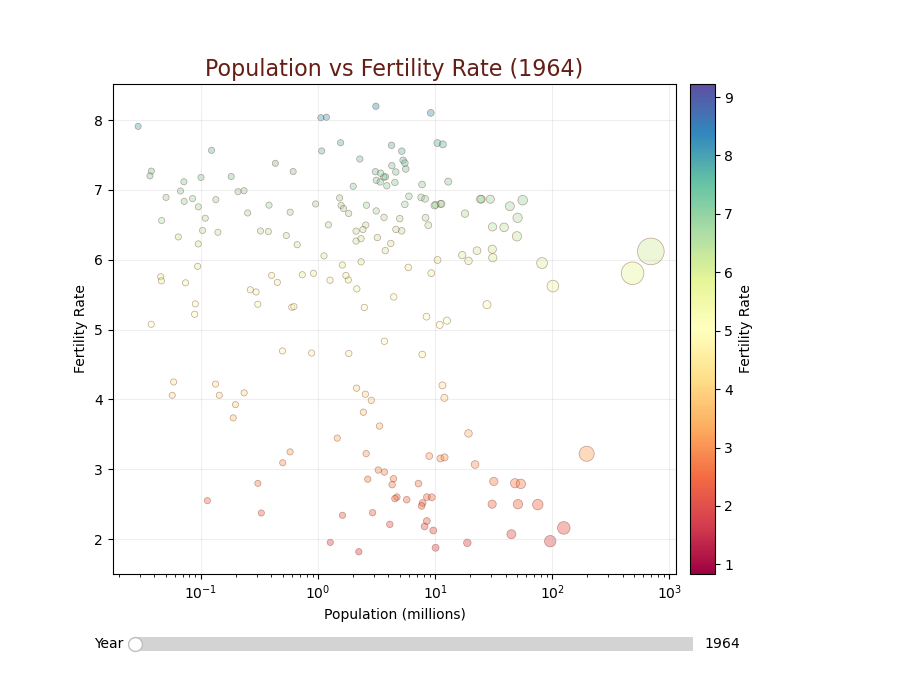

In [2]:
%matplotlib ipympl

from bokeh.sampledata.gapminder import population as pop_data
from bokeh.sampledata.gapminder import fertility as fert_data
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.widgets import Slider

fert_data = fert_data.dropna()
pop_data = pop_data.drop(pop_data.index.difference(fert_data.index))
pop_data = pop_data / 1_000_000  # population in millions

max_fert_data = fert_data.max().max()
min_fert_data = fert_data.min().min()
max_pop_data = pop_data.max().max()
min_pop_data = pop_data.min().min()
years = [int(year) for year in pop_data.columns]

def radii_matplotlib(population, min_population, max_population):
    min_radius = 20
    max_radius = 700
    return min_radius + (population - min_population) / (max_population - min_population) * (max_radius - min_radius)

initial_year = years[0]
initial_year_key = str(initial_year)

fig_mpl, ax_mpl = plt.subplots(figsize=(9, 7))
fig_mpl.canvas.header_visible = False
fig_mpl.subplots_adjust(bottom=0.18, right=0.88)

norm_mpl = Normalize(vmin=min_fert_data, vmax=max_fert_data)
cmap_mpl = plt.get_cmap('Spectral')
scalar_mappable_mpl = ScalarMappable(norm=norm_mpl, cmap=cmap_mpl)
colorbar_mpl = fig_mpl.colorbar(scalar_mappable_mpl, ax=ax_mpl, pad=0.02)
colorbar_mpl.set_label('Fertility Rate')

scatter_mpl = ax_mpl.scatter(
    pop_data[initial_year_key],
    fert_data[initial_year_key],
    s=radii_matplotlib(pop_data[initial_year_key], min_pop_data, max_pop_data),
    c=fert_data[initial_year_key],
    cmap=cmap_mpl,
    norm=norm_mpl,
    alpha=0.4,
    edgecolors='#641e16',
    linewidths=0.5,
)

ax_mpl.set_xscale('log')
ax_mpl.set_xlabel('Population (millions)')
ax_mpl.set_ylabel('Fertility Rate')
title_mpl = ax_mpl.set_title(
    f'Population vs Fertility Rate ({initial_year})',
    color='#641e16',
    fontsize=16,
    )
ax_mpl.grid(True, alpha=0.2)

slider_ax = fig_mpl.add_axes([0.15, 0.06, 0.62, 0.04])
year_slider_mpl = Slider(
    ax=slider_ax,
    label='Year',
    valmin=min(years),
    valmax=max(years),
    valinit=initial_year,
    valstep=years,
    color='cadetblue',
)

def update_matplotlib(year):
    year_key = str(int(year))
    x = pop_data[year_key].to_numpy()
    y = fert_data[year_key].to_numpy()
    sizes = radii_matplotlib(pop_data[year_key], min_pop_data, max_pop_data).to_numpy()
    colors = fert_data[year_key].to_numpy()

    scatter_mpl.set_offsets(list(zip(x, y)))
    scatter_mpl.set_sizes(sizes)
    scatter_mpl.set_array(colors)
    title_mpl.set_text(f'Population vs Fertility Rate ({int(year)})')
    fig_mpl.canvas.draw_idle()

year_slider_mpl.on_changed(update_matplotlib)
plt.show()